In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import check_random_state
random_ = check_random_state(12345)

In [2]:

print("Loading small matrix...")
small_matrix = pd.read_csv("data/small_matrix.csv")

print("Loading item features...")
item_categories = pd.read_csv("data/item_categories.csv")
item_categories["feat"] = item_categories["feat"].map(eval)

print("Loading items' daily features...")
item_daily_features = pd.read_csv("data/item_daily_features.csv")

print("Loading caption features...")
kuairec_caption_category = pd.read_csv("data/kuairec_caption_category.csv", lineterminator='\n')

print("All data loaded.")

Loading small matrix...
Loading item features...
Loading items' daily features...
Loading caption features...
All data loaded.


In [3]:
category_id = kuairec_caption_category.filter(items=["video_id", "first_level_category_id", "second_level_category_id", "third_level_category_id"])

matrix = small_matrix[["user_id", "video_id", "watch_ratio"]]
merged_df = pd.merge(matrix, item_categories, on='video_id')
merged_df = pd.merge(merged_df, category_id, on='video_id')

result_df = merged_df[["user_id", "video_id", "feat", "first_level_category_id", "second_level_category_id", "third_level_category_id", "watch_ratio"]]

In [4]:
df = result_df[result_df["feat"].apply(lambda x: len(x) <= 1)].copy()  
df.loc[:, "feat"] = df["feat"].apply(lambda x: x[0] if len(x) == 1 else None) 

In [5]:
# Keep only one video_id for duplicate sets of action features.
df['watch_ratio'] = (
    df.groupby(['user_id', 'feat', 'first_level_category_id', 'second_level_category_id', 'third_level_category_id'])['watch_ratio']
    .transform('mean')  # Calculate the average of watch_ratio for each group and apply it.
)

df_deduplicated = df.drop_duplicates(subset=['feat', 'first_level_category_id', 'second_level_category_id', 'third_level_category_id'])
unique_video_ids = df_deduplicated['video_id'].unique()

# Extract rows from df that contain unique video_id
df = df[df['video_id'].isin(unique_video_ids)]

df.nunique()


user_id                       1411
video_id                       377
feat                            29
first_level_category_id         38
second_level_category_id        95
third_level_category_id        132
watch_ratio                 508759
dtype: int64

In [6]:
top_values = df["feat"].value_counts().nlargest(15).index
df = df[df["feat"].isin(top_values)].copy()

top_values = df["first_level_category_id"].value_counts().nlargest(15).index
df = df[df["first_level_category_id"].isin(top_values)].copy()

top_values = df["second_level_category_id"].value_counts().nlargest(17).index
df = df[df["second_level_category_id"].isin(top_values)].copy()

top_values = df["third_level_category_id"].value_counts().nlargest(15).index
df = df[df["third_level_category_id"].isin(top_values)].copy()

In [7]:

unique_combinations = df.groupby(['feat', 
'first_level_category_id', 'second_level_category_id', 'third_level_category_id']).ngroups
print(f"Unique combinations: {unique_combinations}")

Unique combinations: 117


In [8]:
df.nunique()

user_id                       1411
video_id                       117
feat                            15
first_level_category_id         15
second_level_category_id        15
third_level_category_id         15
watch_ratio                 159259
dtype: int64

In [9]:

numeric_columns = ["feat", "first_level_category_id", "second_level_category_id", "third_level_category_id", "watch_ratio"]

# Retrieve unique pairs of user_id and video_id
existing_pairs = set(zip(df["user_id"], df["video_id"]))

# Generate all possible combinations of user_id and video_id
all_user_ids = df["user_id"].unique()
all_video_ids = df["video_id"].unique()
all_combinations = {(user_id, video_id) for user_id in all_user_ids for video_id in all_video_ids}

# Retrieve the pairs of user_id and video_id that do not exist in the dataset
missing_pairs = all_combinations - existing_pairs

# Create new rows for the missing pairs
new_rows = []
for user_id, video_id in missing_pairs:
    # Calculate the mean of each numeric column for the video_id
    row = {"user_id": user_id, "video_id": video_id}
    for col in numeric_columns:
        row[col] = df[df["video_id"] == video_id][col].mean()
    new_rows.append(row)

# Convert the list of new rows to a DataFrame
new_rows_df = pd.DataFrame(new_rows)

# Append the new rows to the original DataFrame
df = pd.concat([df, new_rows_df], ignore_index=True)

df

,user_id,video_id,feat,first_level_category_id,second_level_category_id,third_level_category_id,watch_ratio
0,14,183,28,28.0,223.0,-124.0,1.200481
1,19,183,28,28.0,223.0,-124.0,1.015954
2,21,183,28,28.0,223.0,-124.0,1.209648
3,23,183,28,28.0,223.0,-124.0,1.368951
4,24,183,28,28.0,223.0,-124.0,1.048093
...,...,...,...,...,...,...,...
165082,3514,169,11.0,34.0,-124.0,-124.0,1.048272
165083,4427,3672,28.0,28.0,223.0,2446.0,0.852571
165084,407,3649,9.0,28.0,223.0,1830.0,1.065700
165085,5624,5374,28.0,28.0,223.0,1838.0,0.962296


In [10]:
df.nunique()

user_id                       1411
video_id                       117
feat                            15
first_level_category_id         15
second_level_category_id        15
third_level_category_id         15
watch_ratio                 159292
dtype: int64

In [11]:
unique_values_video_id = {value: idx for idx, value in enumerate(df["video_id"].unique())}
df["video_id"] = df["video_id"].map(unique_values_video_id)

unique_values_feat = {value: idx for idx, value in enumerate(df["feat"].unique())}
df["feat"] = df["feat"].map(unique_values_feat)

unique_values_first_level_category_id = {value: idx for idx, value in enumerate(df["first_level_category_id"].unique())}
df["first_level_category_id"] = df["first_level_category_id"].map(unique_values_first_level_category_id)

unique_values_second_level_category_id = {value: idx for idx, value in enumerate(df["second_level_category_id"].unique())}
df["second_level_category_id"] = df["second_level_category_id"].map(unique_values_second_level_category_id)

unique_values_third_level_category_id = {value: idx for idx, value in enumerate(df["third_level_category_id"].unique())}
df["third_level_category_id"] = df["third_level_category_id"].map(unique_values_third_level_category_id)

count    165087.000000
mean          0.889022
std           0.949756
min           0.000000
25%           0.574508
50%           0.802740
75%           1.051335
max          95.640317
Name: watch_ratio, dtype: float64


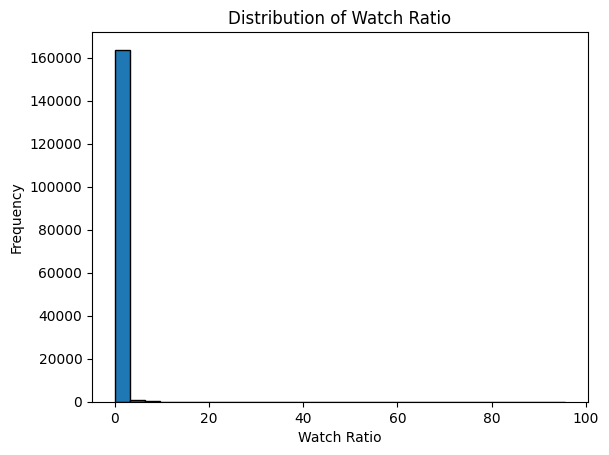

In [12]:
print(df["watch_ratio"].describe())
import matplotlib.pyplot as plt

plt.hist(df["watch_ratio"], bins=30, edgecolor='k')
plt.xlabel("Watch Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Watch Ratio")
plt.show()


count    165087.000000
mean          0.294131
std           0.159888
min           0.000000
25%           0.196588
50%           0.274685
75%           0.359751
max           1.000000
Name: watch_ratio, dtype: float64


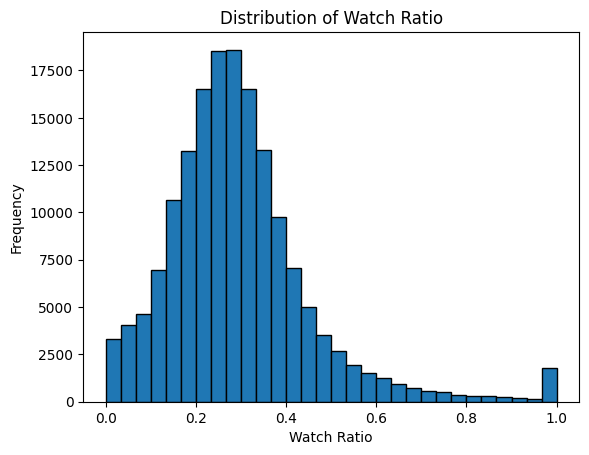

In [13]:

# Remove outliers
upper_limit = df["watch_ratio"].quantile(0.99)
df["watch_ratio"] = df["watch_ratio"].clip(upper=upper_limit)

# Normalize the watch_ratio column
scaler = MinMaxScaler(feature_range=(0, 1))

df["watch_ratio"] = pd.DataFrame(scaler.fit_transform(df["watch_ratio"].values.reshape(-1, 1)), columns=["watch_ratio"])

print(df["watch_ratio"].describe())
import matplotlib.pyplot as plt

plt.hist(df["watch_ratio"], bins=30, edgecolor='k')
plt.xlabel("Watch Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Watch Ratio")
plt.show()


In [14]:
file_path = 'data/processed_all_data.csv'
df.to_csv(file_path, index=False)

In [15]:
df_unique = df.drop_duplicates(subset=["video_id", "feat", "first_level_category_id", "second_level_category_id", "third_level_category_id"], keep='first')

In [16]:
df_unique

,user_id,video_id,feat,first_level_category_id,second_level_category_id,third_level_category_id,watch_ratio
0,14,0,0,0,0,0,0.410786
1411,14,1,1,0,0,1,0.588435
2793,14,2,2,1,1,0,0.225876
4204,14,3,1,0,0,2,0.676385
5612,14,4,0,0,0,1,0.337920
...,...,...,...,...,...,...,...
157703,14,112,8,4,1,0,0.233530
159114,14,113,8,5,9,0,0.214635
160525,14,114,5,4,3,0,0.316193
161935,14,115,12,5,9,0,0.423973


In [17]:
file_path = 'data/processed_unique_action.csv'
df_unique.to_csv(file_path, index=False)

# user_feature



In [18]:
# # load data
print("Loading user features...")
file_path = 'data/user_features.csv'
data = pd.read_csv(file_path)

user_ids = data['user_id']

# Apply the process to all columns except user_id.
data = data.drop(columns=['user_id'])

# Perform One-Hot Encoding for categorical features
categorical_cols = ['user_active_degree', 'follow_user_num_range', 'fans_user_num_range']
data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

# Fill missing values with 0.
data = data.fillna(0)

# Standardize numerical features
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
data[numerical_cols] = scaler.fit_transform(data[numerical_cols])

delete_column = data.columns.values[data.dtypes == object]
data = data.drop(delete_column, axis=1)


# PCA
pca = PCA(n_components=10) 
data_pca = pca.fit_transform(data)

# Create a DataFrame for the compressed data
data_pca = pd.DataFrame(data_pca, columns=[f'PC{i+1}' for i in range(data_pca.shape[1])])
data_pca['user_id'] = user_ids

# Save the compressed data to a CSV file
compressed_file_path = 'data/processed_user_feature.csv'
data_pca.to_csv(compressed_file_path, index=False)



Loading user features...
